In [23]:
import scanpy as sc
import anndata as ad
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

In [24]:
# load matrix
X = io.mmread("merged.codex.counts.mtx")

# create anndata object
adata = ad.AnnData(
    X=X.transpose().tocsr()
)

# load metadata
cell_meta = pd.read_csv("merged.codex.metadata.csv", low_memory=False)

# load gene names
with open("merged.codex.gene.names.csv", 'r') as f:
    gene_names = f.read().splitlines()

# set anndata observations and index obs by barcodes, var by gene names
adata.obs = cell_meta
adata.obs.index = adata.obs['barcode']
adata.var.index = gene_names

In [25]:
adata

AnnData object with n_obs × n_vars = 140128 × 29
    obs: 'orig.ident', 'nCount_Multiplex', 'nFeature_Multiplex', 'Multiplex_snn_res.0.5', 'seurat_clusters', 'Cell.type', 'basal_no_myo', 'Cell.type.basal.hybrid', 'norm_roi', 'rois', 'sample', 'norm_roi_1', 'norm_roi_2', 'norm_roi_3', 'hyper_roi_1', 'hyper_roi_2', 'hyper_roi_3', 'Multiplex_snn_res.1', 'Multiplex_snn_res.0.75', 'Multiplex_snn_res.0.25', 'Multiplex_snn_res.0.35', 'Multiplex_snn_res.0.2', 'Multiplex_snn_res.0.4', 'roi', 'hyper_roi', 'barcode'

In [27]:
adata.obs['roi_name'] = (
    adata.obs["rois"]
    .map(lambda x: {0: "outside",
                   1:"normal_like",
                   2:"hyperplasia"}.get(x, x))
    .astype("category")
)

In [28]:
adata.obs["Cell_type_basal_hybrid"] = (
    adata.obs["Cell.type.basal.hybrid"]
    .map(lambda x: {
        "basal_no_myo": "basal"
    }.get(x, x))
    .astype('category')
)

In [29]:
adata.obs["condition"] = (
    adata.obs["sample"]
    .map(lambda x: {
        "wt_1": "WT",
        "wt_2": "WT",
        "wt_3": "WT",
        "mut_1": "MUT",
        "mut_2": "MUT",
        "mut_3": "MUT",
        "tum_1": "TUM",
        "tum_2": "TUM",
        "tum_3": "TUM",
    }.get(x, x))
    .astype('category')
)

In [ ]:
adata.write_h5ad("merged_codex.h5ad")

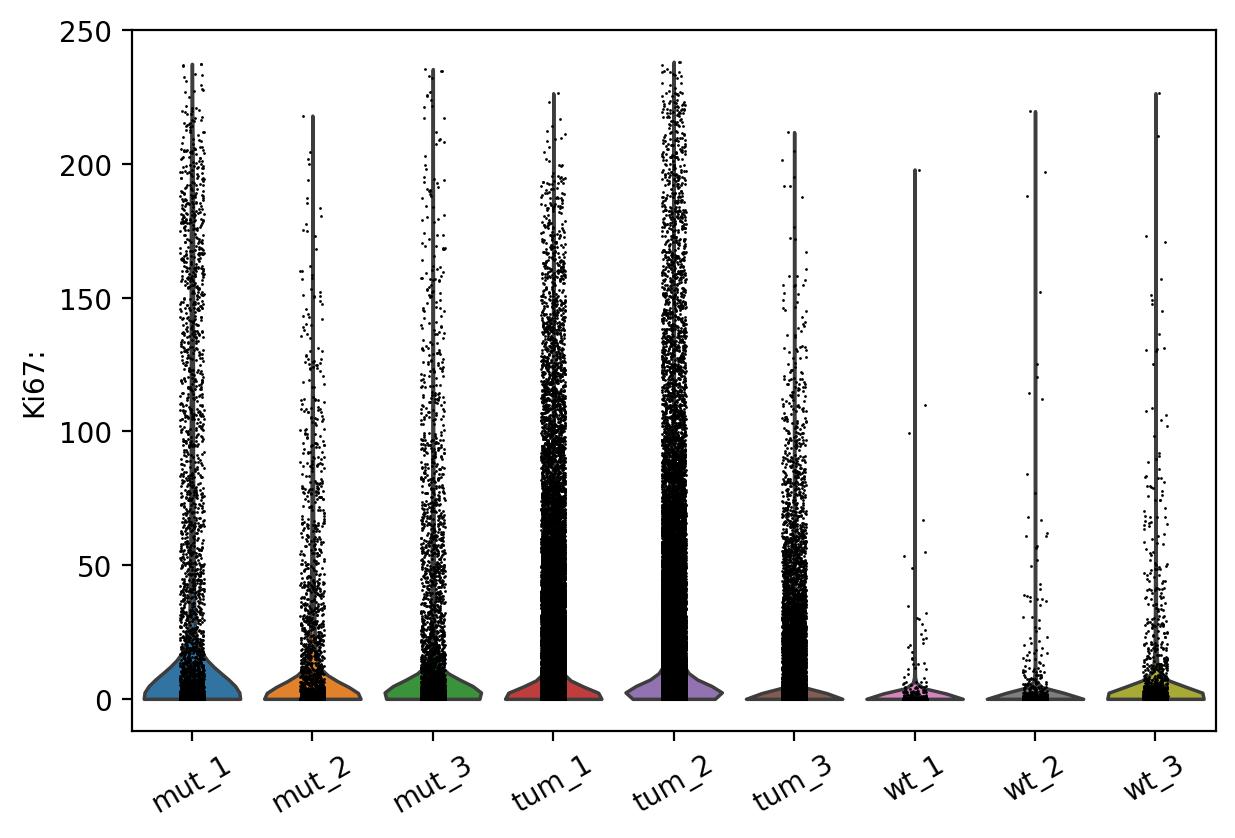

In [197]:
sc.pl.violin(adata, ["Ki67:"], groupby="sample", 
             rotation=30)

In [281]:
# Define your parameters
gene_of_interest = "Ki67:"
expression_threshold = 50
suffix = "_prolif"

# 1. Identify cells above the threshold
# Note: Use .toarray() if your matrix is sparse
expression_values = adata[:, gene_of_interest].X
if hasattr(expression_values, "toarray"):
    expression_values = expression_values.toarray()

is_above = expression_values.flatten() > expression_threshold

# 2. Convert existing category column to string to allow editing
adata.obs["Cell.type.prolif"] = adata.obs["Cell_type_basal_hybrid"].astype(str)

# 3. Add suffix only to the matching rows
adata.obs.loc[is_above, "Cell.type.prolif"] = adata.obs.loc[is_above, "Cell.type.prolif"] + suffix

# 4. Convert back to category for Scanpy plotting efficiency
adata.obs["Cell.type.prolif"] = adata.obs["Cell.type.prolif"].astype("category")

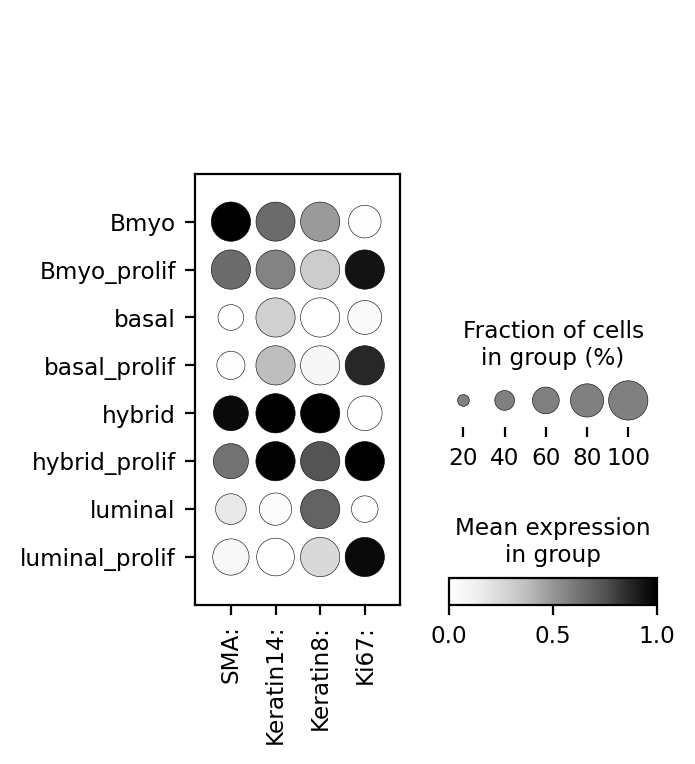

In [282]:
marker_genes = ["SMA:","Keratin14:","Keratin8:","Ki67:"]

plt.style.use('default')
sc.pl.dotplot(adata, marker_genes, groupby="Cell.type.prolif",
              standard_scale="var",swap_axes=False,cmap='Greys',
              #save='_wt_canonical.pdf'
             )

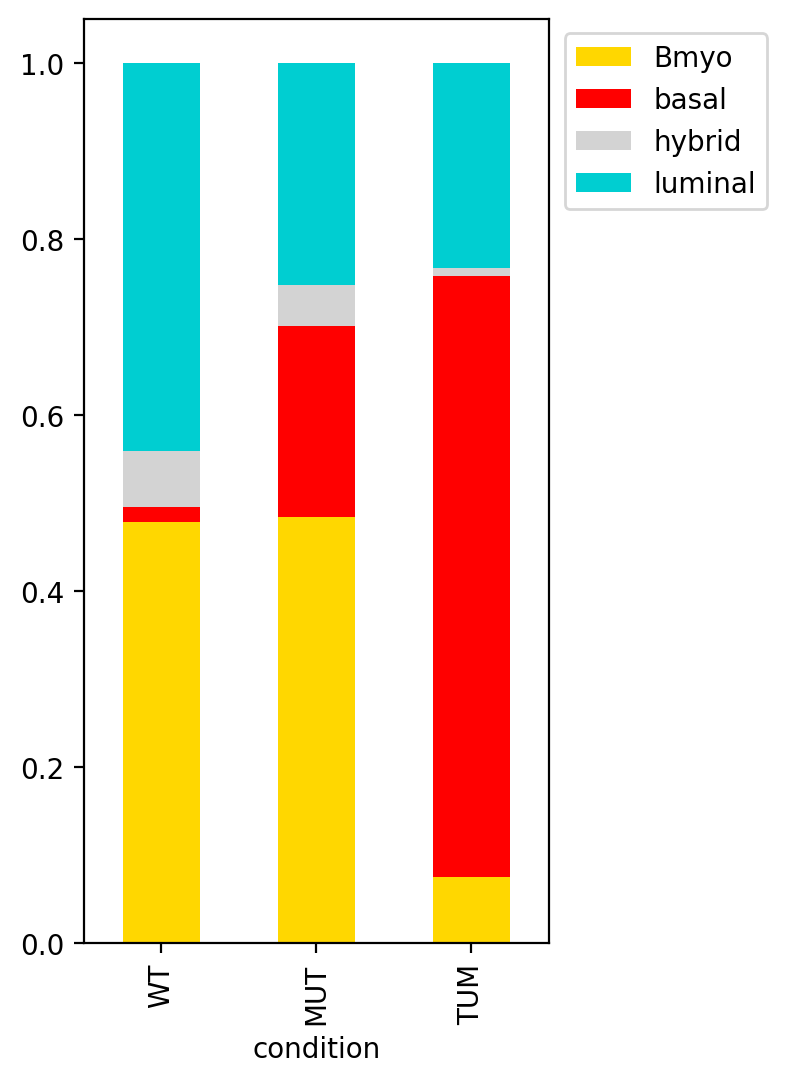

In [257]:
pl.rcParams["figure.figsize"] = (3,6)

tmp = pd.crosstab(adata.obs['Cell_type_basal_hybrid'],adata.obs['condition'], 
                  normalize='columns').reindex()[['WT',
                                                  'MUT',
                                                 'TUM']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_cell_freq_stackedbar_plot.pdf', bbox_inches='tight')

In [258]:
sub = adata[adata.obs['roi_name'].isin(['normal_like','hyperplasia'])]
sub.obs['roi_name'].value_counts()

roi_name
hyperplasia    61402
normal_like     5280
Name: count, dtype: int64

In [259]:
sub.obs['condition'].value_counts()

condition
TUM    53457
MUT    10061
WT      3164
Name: count, dtype: int64

In [260]:
sub.obs['condition'] = sub.obs["condition"].astype("str")
sub.obs['roi_name'] = sub.obs["roi_name"].astype("str")
sub.obs['condition_ROI'] = sub.obs['condition'] + '_' + sub.obs['roi_name']

/tmp/ipykernel_81008/3967299658.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs['condition'] = sub.obs["condition"].astype("str")


In [261]:
sub.obs['condition_ROI'].value_counts()

condition_ROI
TUM_hyperplasia    53457
MUT_hyperplasia     7945
WT_normal_like      3164
MUT_normal_like     2116
Name: count, dtype: int64

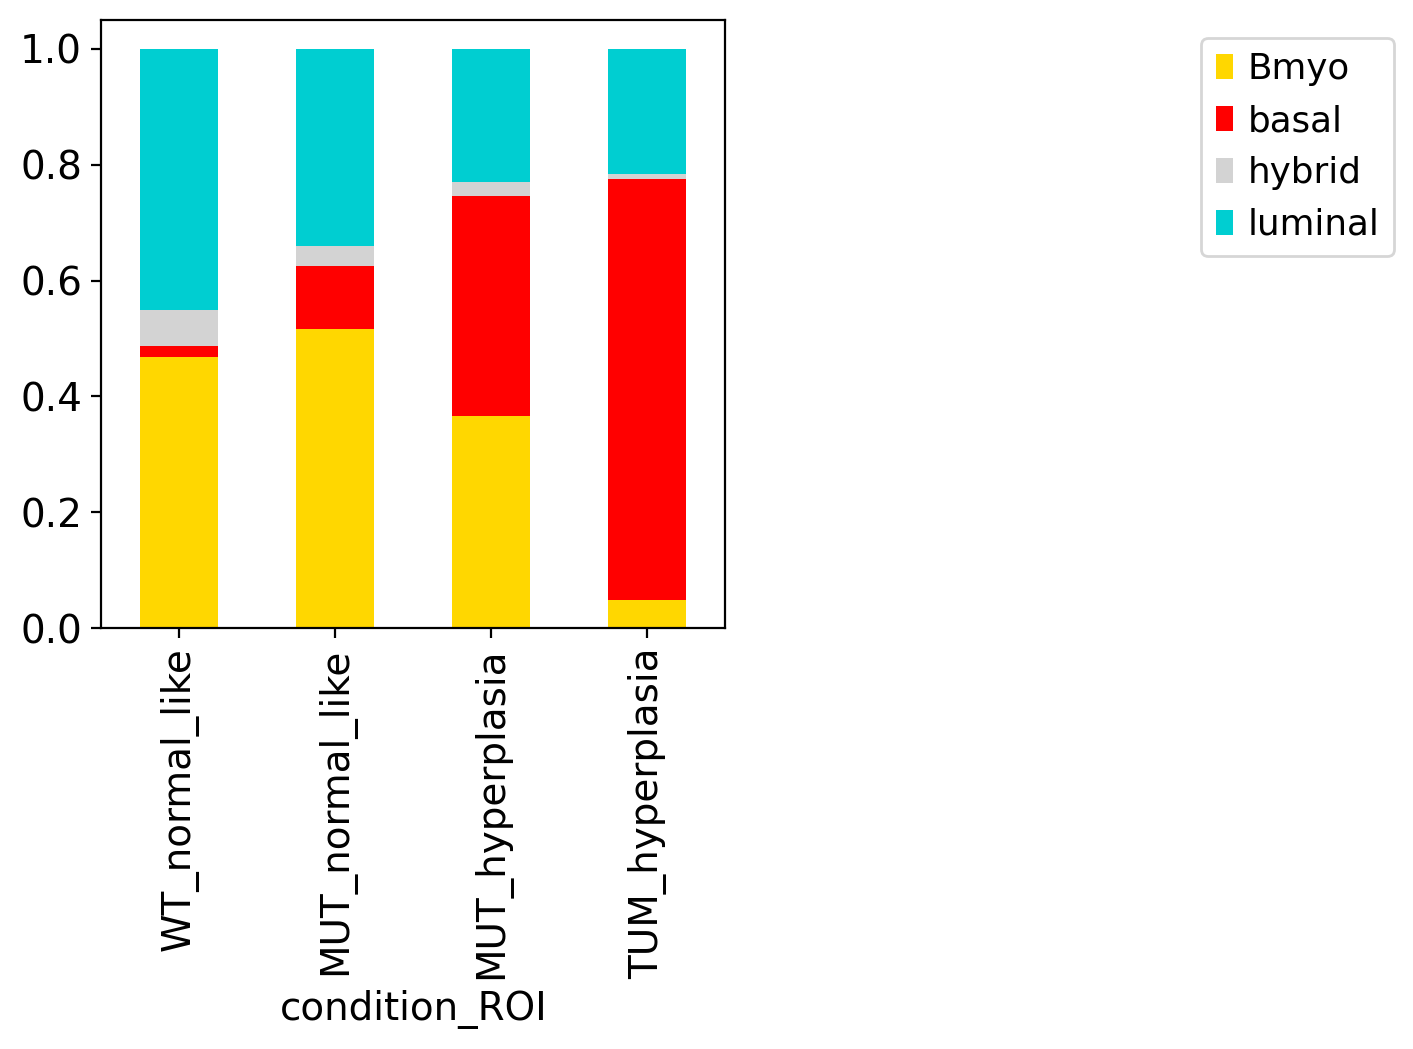

In [137]:
pl.rcParams["figure.figsize"] = (4,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['condition_ROI'], 
                  normalize='columns').reindex()[['WT_normal_like',
                                                  'MUT_normal_like',
                                                                                        'MUT_hyperplasia',
                                                                                        'TUM_hyperplasia']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_raw_stackedbar_plot.pdf', bbox_inches='tight')

/tmp/ipykernel_81008/153103130.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  pl.tight_layout()


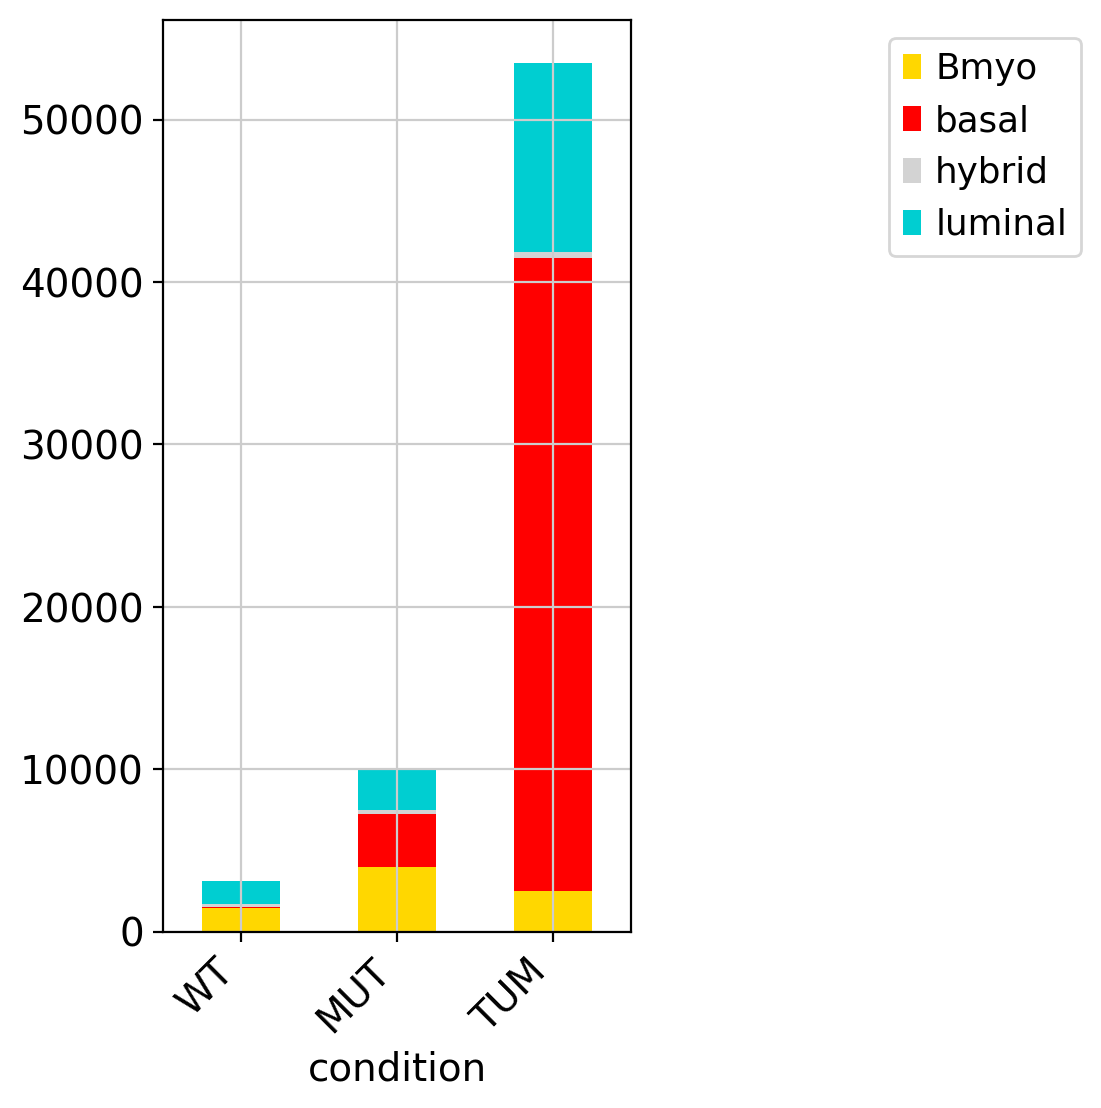

In [158]:
pl.rcParams["figure.figsize"] = (3,6)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['condition']).reindex()[['WT',
                                                                                        'MUT',
                                                                                        'TUM']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.0, 1.0),loc='upper right')
pl.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
pl.tight_layout()

#pl.savefig('Fig_6_celltype_freq_raw_stackedbar_plot.pdf', bbox_inches='tight')

In [159]:
hybrid=adata[adata.obs['Cell_type_basal_hybrid'].isin(['hybrid'])]

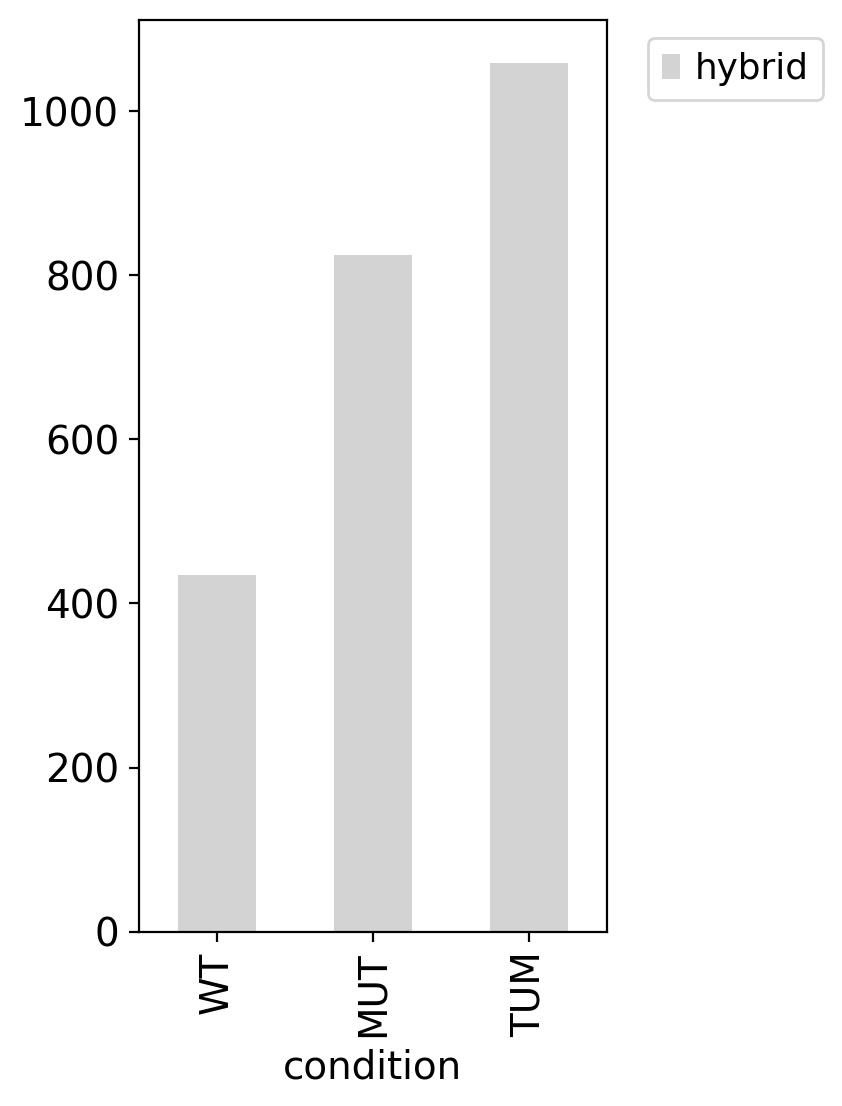

In [164]:
pl.rcParams["figure.figsize"] = (3,6)

tmp = pd.crosstab(hybrid.obs['Cell_type_basal_hybrid'],hybrid.obs['condition']).reindex()[['WT',
                                                  'MUT',
                                                                                        'TUM']].T.plot(kind='bar', stacked=True, color=['lightgrey'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_hybrid_raw_stackedbar_plot.pdf', bbox_inches='tight')

In [162]:
basal=adata[adata.obs['Cell_type_basal_hybrid'].isin(['basal'])]

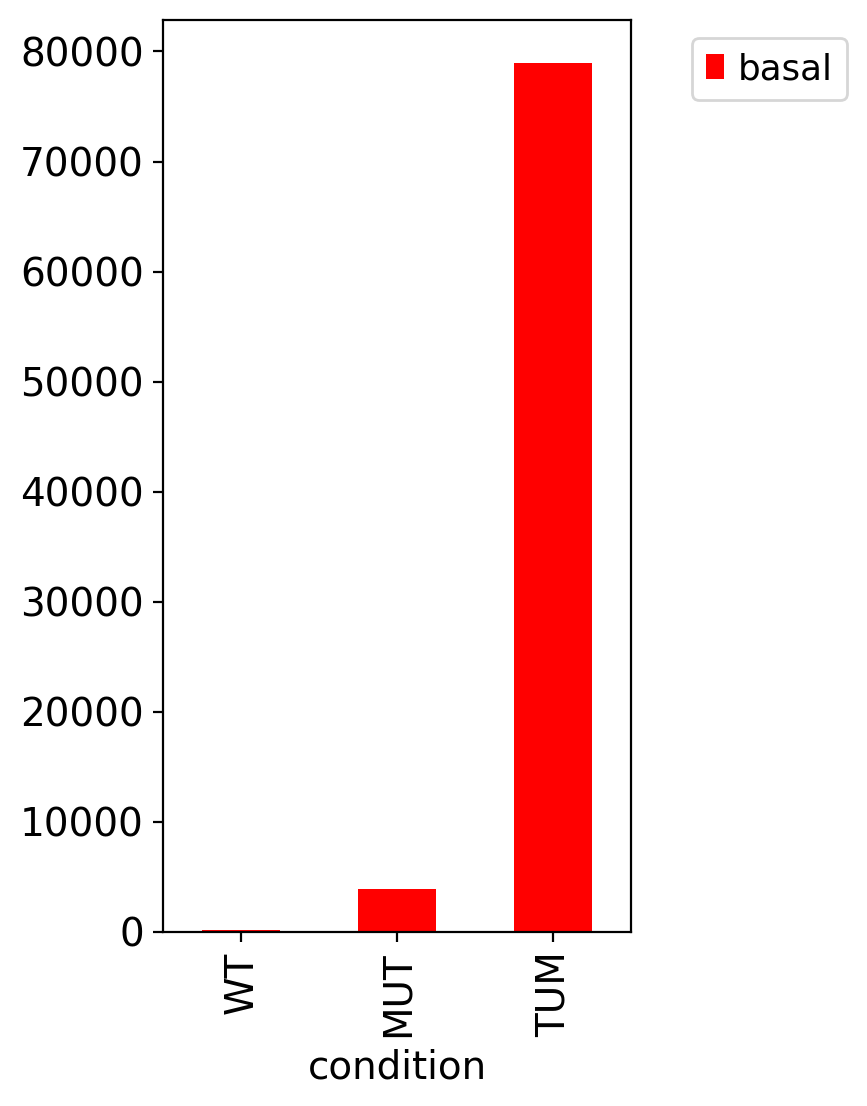

In [165]:
pl.rcParams["figure.figsize"] = (3,6)

tmp = pd.crosstab(basal.obs['Cell_type_basal_hybrid'],basal.obs['condition']).reindex()[['WT',
                                                  'MUT',
                                                                                        'TUM']].T.plot(kind='bar', stacked=True, color=['red'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_basal_raw_stackedbar_plot.pdf', bbox_inches='tight')

In [46]:
hybrid=sub[sub.obs['Cell_type_basal_hybrid'].isin(['hybrid'])]

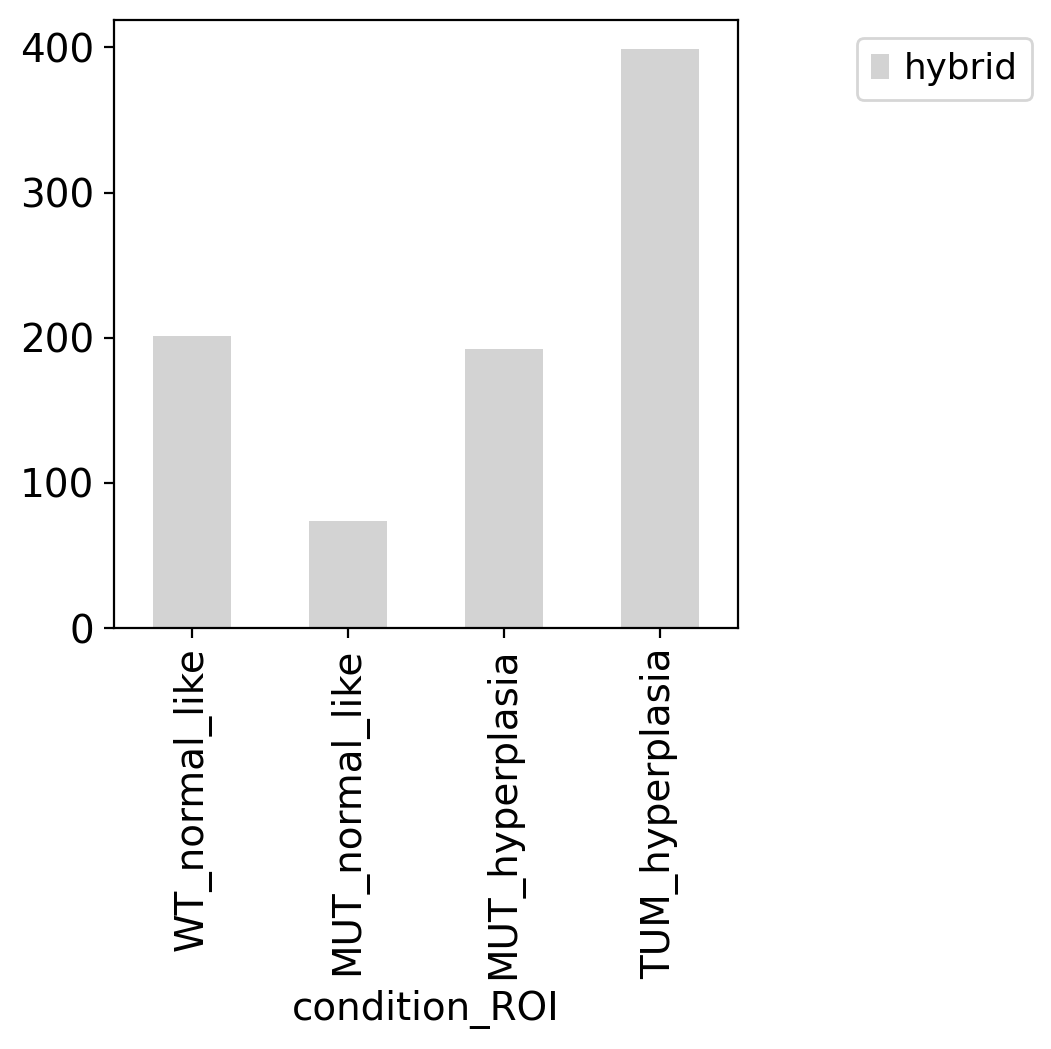

In [47]:
pl.rcParams["figure.figsize"] = (4,4)

tmp = pd.crosstab(hybrid.obs['Cell_type_basal_hybrid'],hybrid.obs['condition_ROI']).reindex()[['WT_normal_like',
                                                  'MUT_normal_like',
                                                                                        'MUT_hyperplasia',
                                                                                        'TUM_hyperplasia']].T.plot(kind='bar', stacked=True, color=['lightgrey'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_raw_stackedbar_plot.pdf', bbox_inches='tight')

In [283]:
#wt
sub = adata[adata.obs['sample'].isin(['wt_1','wt_2','wt_3'])]
sub.obs['sample'].value_counts()

sample
wt_3    2858
wt_2    2720
wt_1    1178
Name: count, dtype: int64

In [284]:
sub.obs['roi_name'].value_counts()

roi_name
outside        3592
normal_like    3164
Name: count, dtype: int64

In [285]:
sub = sub[sub.obs['roi_name'].isin(['normal_like'])]
sub.obs['norm_roi_3'].value_counts()

norm_roi_3
5.0    534
9.0    519
8.0    497
7.0    411
1.0    328
2.0    315
4.0    217
6.0    196
3.0    147
Name: count, dtype: int64

/tmp/ipykernel_81008/767117481.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['norm_roi_3', 'Cell.type.prolif'])
/tmp/ipykernel_81008/767117481.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/767117481.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts,


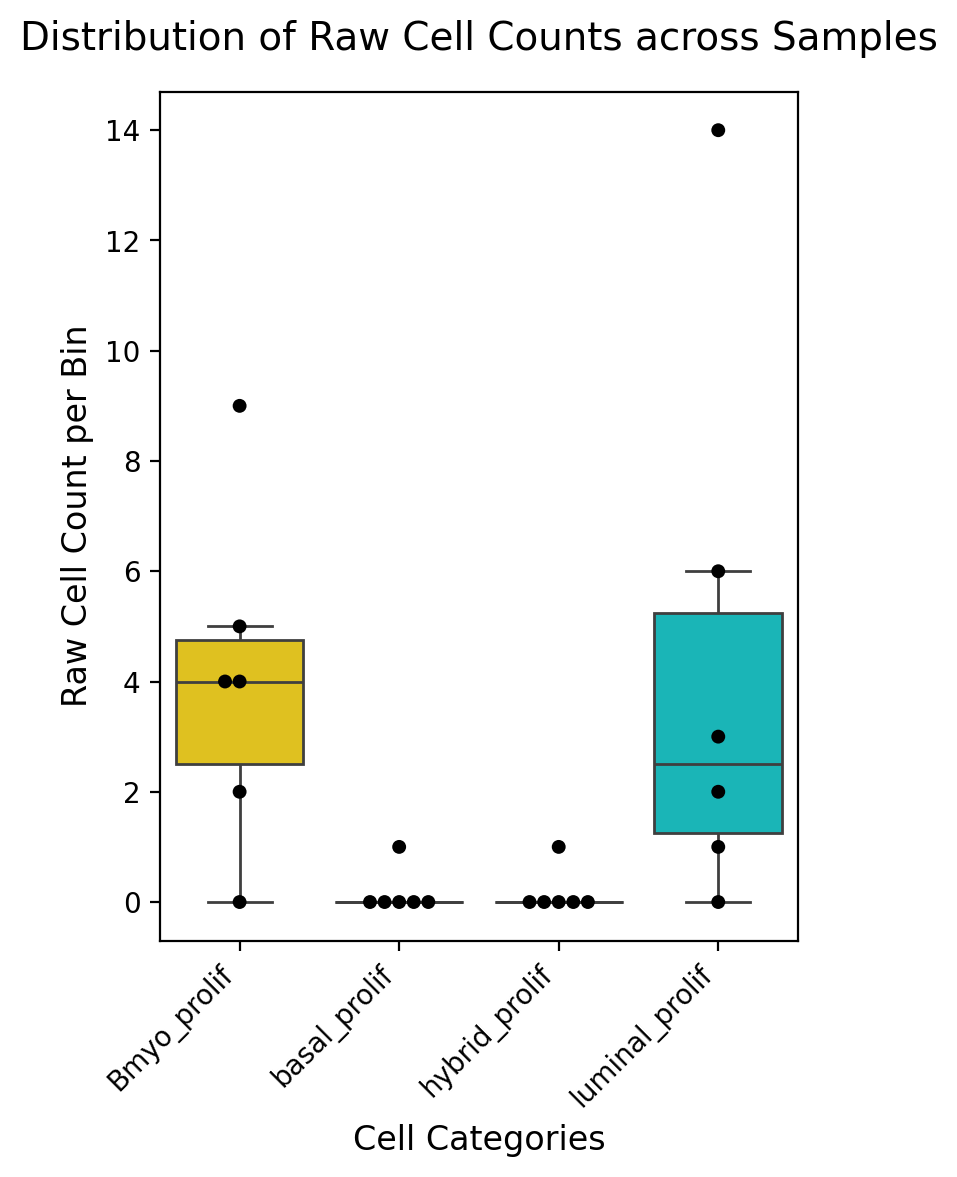

In [289]:
subsub = sub[sub.obs['Cell.type.prolif'].isin(['Bmyo_prolif','basal_prolif','hybrid_prolif','luminal_prolif'])]
df_meta = subsub.obs[['norm_roi_3', 'Cell.type.prolif']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['norm_roi_3', 'Cell.type.prolif'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo_prolif': 'gold',     # Nice slate blue
    'basal_prolif': 'red',     # Orange
    'hybrid_prolif': 'lightgray', # Green
    'luminal_prolif': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell.type.prolif',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('WT_ROI_proliferation_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

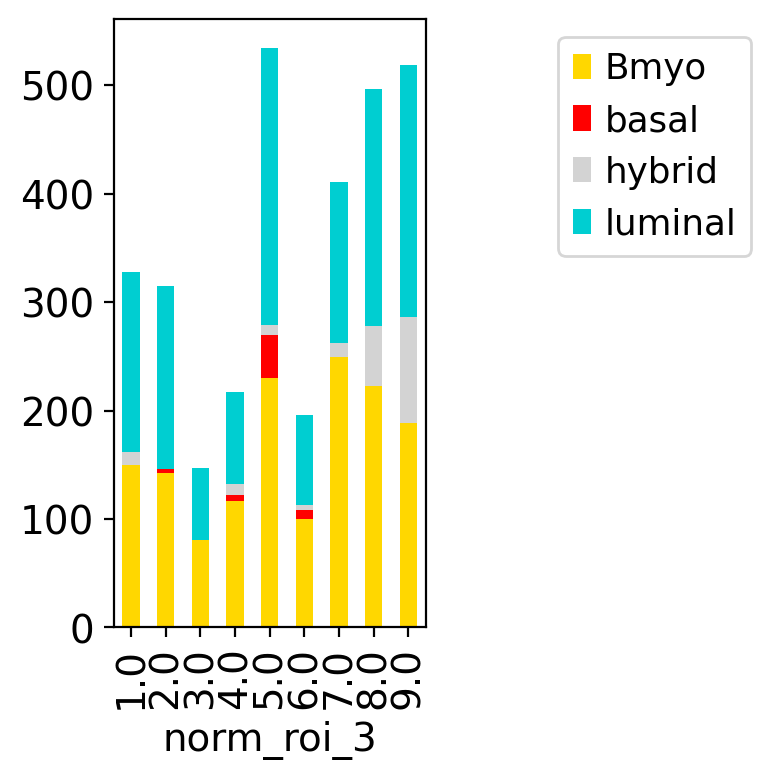

In [115]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['norm_roi_3']).T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_stackedbar_plot.pdf', bbox_inches='tight')

/tmp/ipykernel_81008/1687917729.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['norm_roi_3', 'Cell_type_basal_hybrid'])
/tmp/ipykernel_81008/1687917729.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/1687917729.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts,


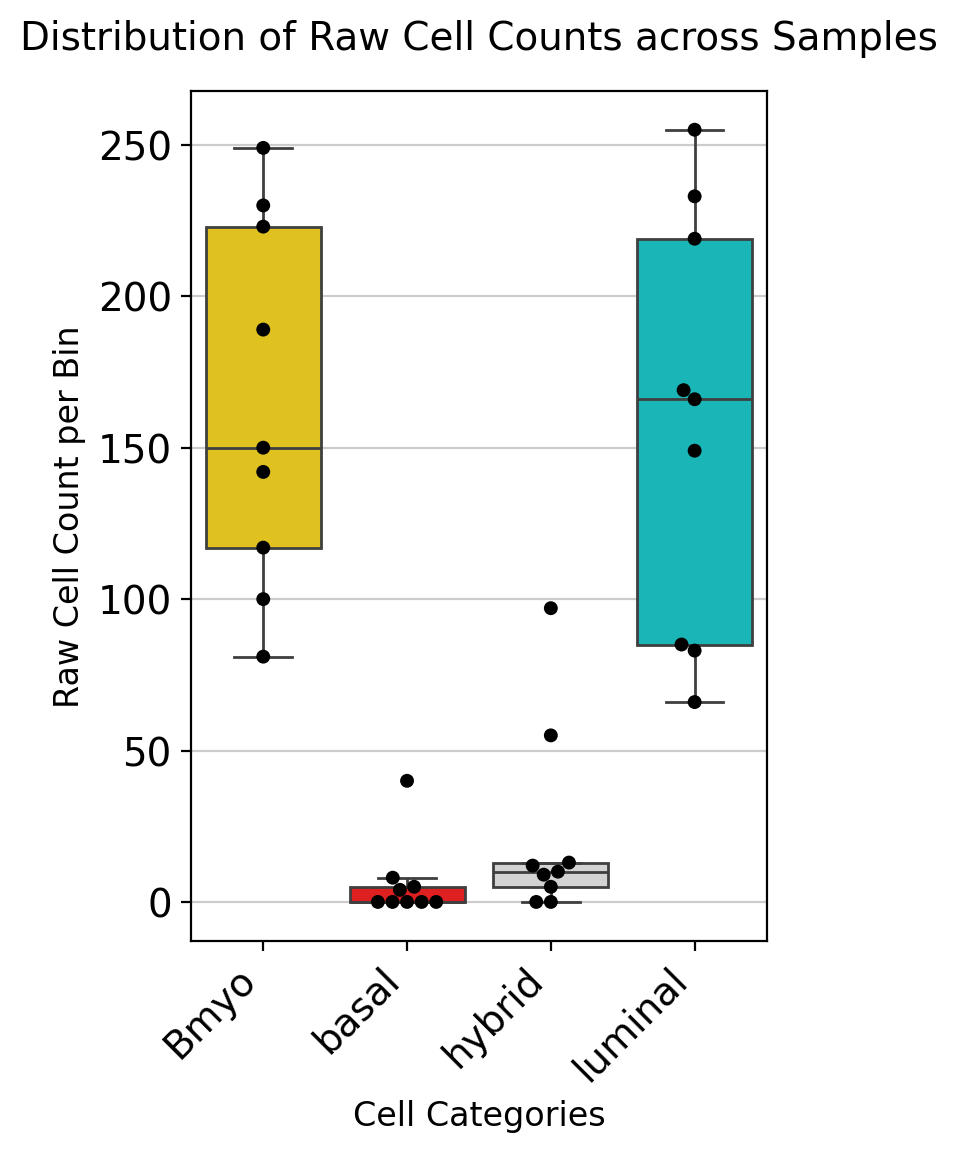

In [117]:
df_meta = sub.obs[['norm_roi_3', 'Cell_type_basal_hybrid']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['norm_roi_3', 'Cell_type_basal_hybrid'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo': 'gold',     # Nice slate blue
    'basal': 'red',     # Orange
    'hybrid': 'lightgray', # Green
    'luminal': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell_type_basal_hybrid',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('WT_ROI_cell_counts_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

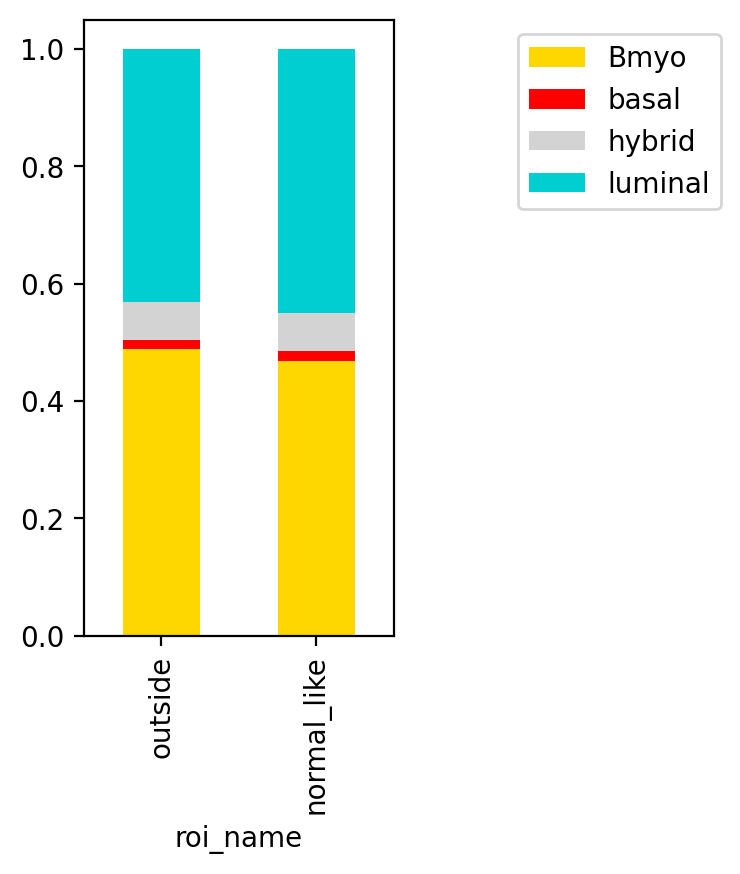

In [88]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name'], 
                  normalize='columns').reindex()[['outside',
                                                  'normal_like']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_WT_stackedbar_plot.pdf', bbox_inches='tight')

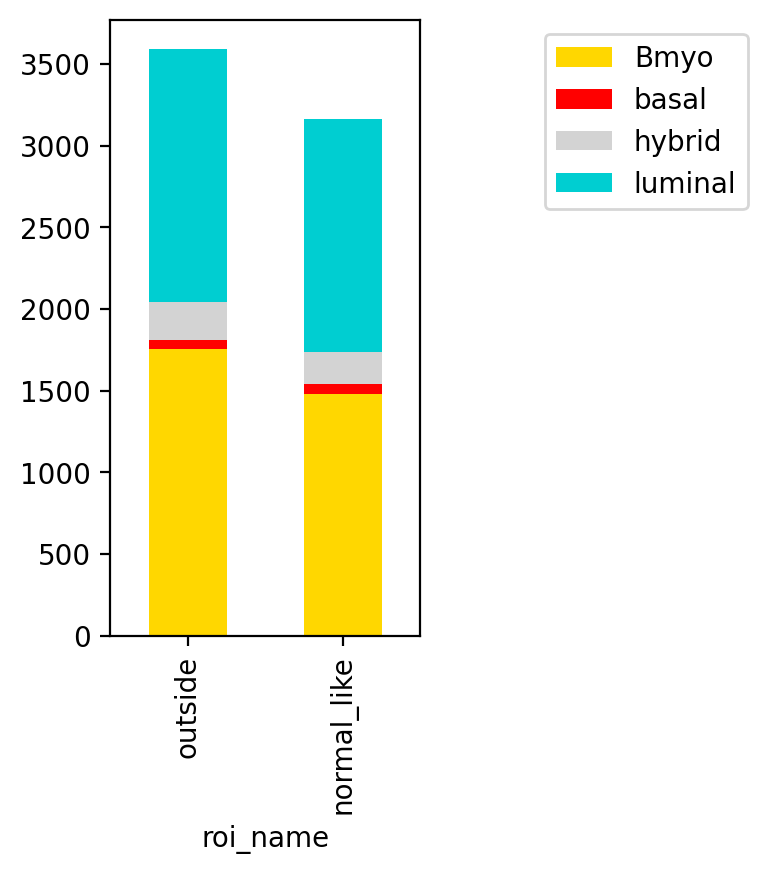

In [89]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name']).reindex()[['outside',
                                                  'normal_like']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_WT_raw_stackedbar_plot.pdf', bbox_inches='tight')

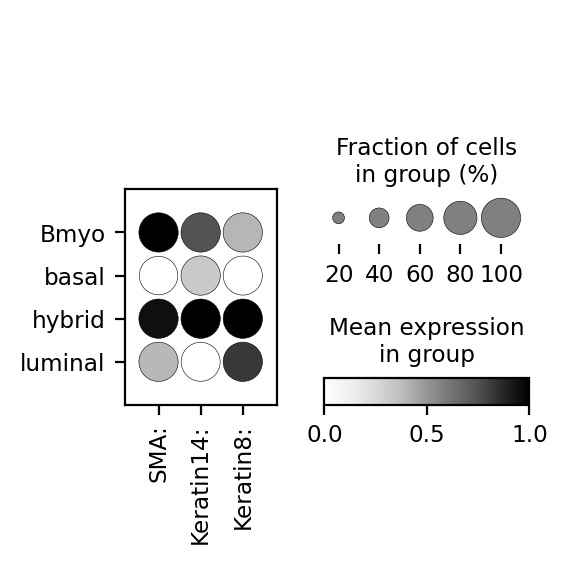

In [174]:
marker_genes = ["SMA:","Keratin14:","Keratin8:"]

plt.style.use('default')
sc.pl.dotplot(sub, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_wt_canonical.pdf'
             )

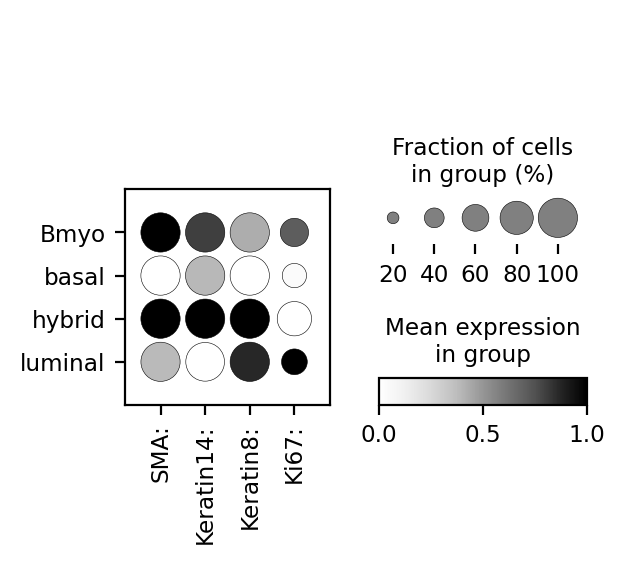

In [188]:
marker_genes = ["SMA:","Keratin14:","Keratin8:","Ki67:"]

plt.style.use('default')
sc.pl.dotplot(sub, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_wt_canonical.pdf'
             )

In [290]:
#mut
sub = adata[adata.obs['sample'].isin(['mut_1','mut_2','mut_3'])]
sub.obs['sample'].value_counts()

sample
mut_3    7405
mut_1    6345
mut_2    3962
Name: count, dtype: int64

In [291]:
sub = sub[sub.obs['roi_name'].isin(['normal_like'])]
sub.obs['norm_roi_3'].value_counts()

norm_roi_3
1.0    507
3.0    355
4.0    299
2.0    273
7.0    248
6.0    236
5.0    198
Name: count, dtype: int64

/tmp/ipykernel_81008/3284580825.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['norm_roi_3', 'Cell.type.prolif'])
/tmp/ipykernel_81008/3284580825.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/3284580825.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts,


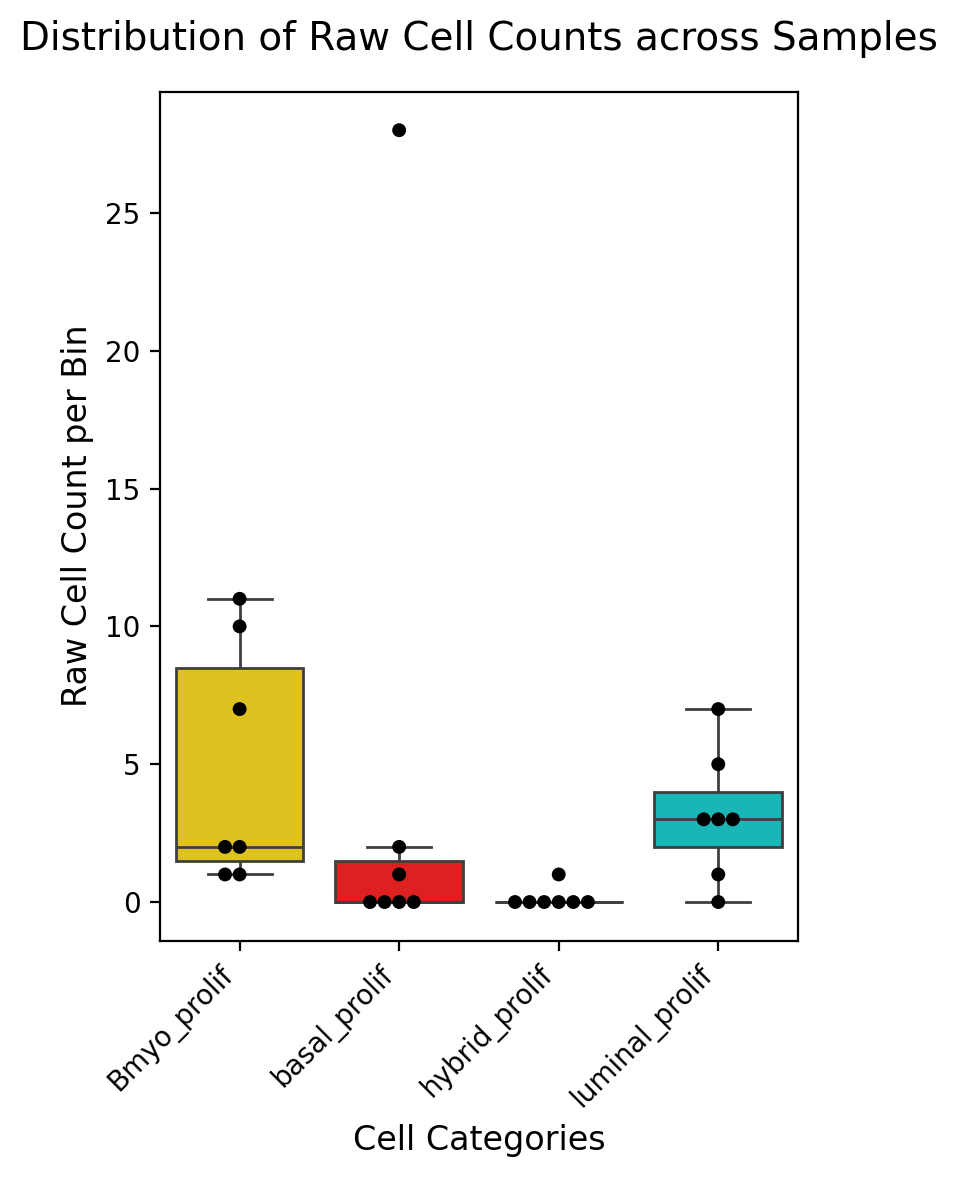

In [293]:
subsub = sub[sub.obs['Cell.type.prolif'].isin(['Bmyo_prolif','basal_prolif','hybrid_prolif','luminal_prolif'])]
df_meta = subsub.obs[['norm_roi_3', 'Cell.type.prolif']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['norm_roi_3', 'Cell.type.prolif'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo_prolif': 'gold',     # Nice slate blue
    'basal_prolif': 'red',     # Orange
    'hybrid_prolif': 'lightgray', # Green
    'luminal_prolif': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell.type.prolif',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('MUT_norm_ROI_proliferation_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

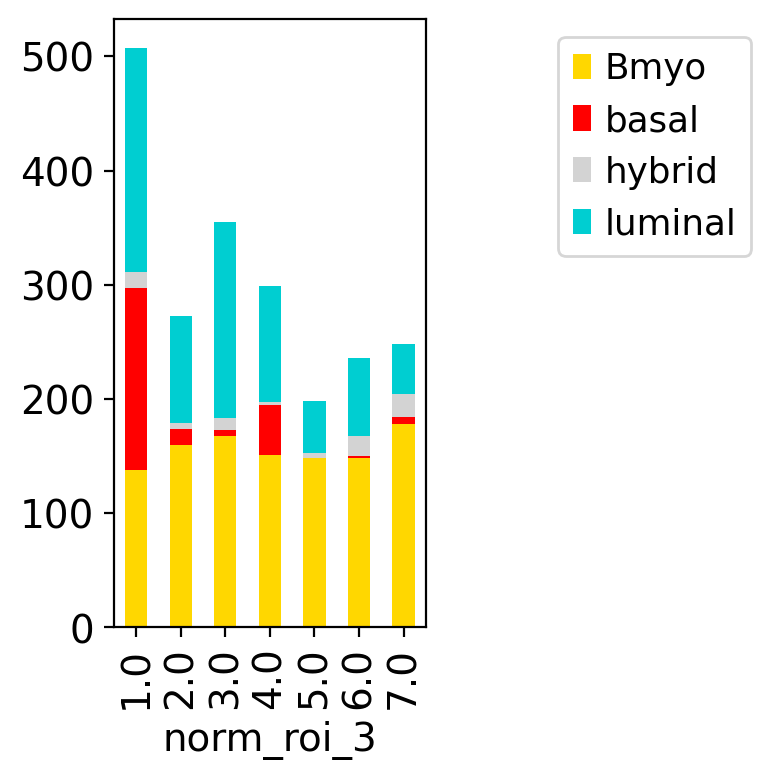

In [120]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['norm_roi_3']).T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_stackedbar_plot.pdf', bbox_inches='tight')

/tmp/ipykernel_81008/3103442175.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['norm_roi_3', 'Cell_type_basal_hybrid'])
/tmp/ipykernel_81008/3103442175.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/3103442175.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts,


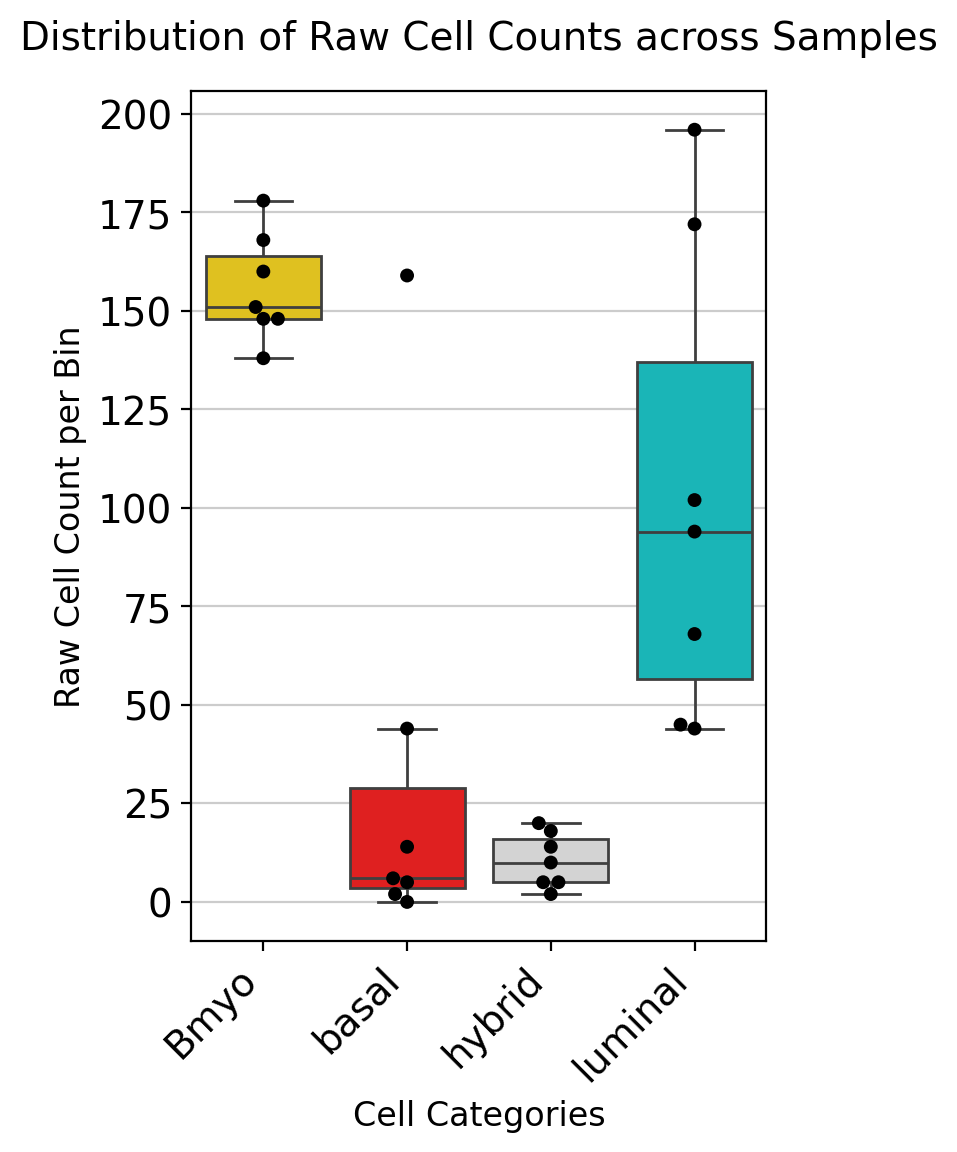

In [121]:
df_meta = sub.obs[['norm_roi_3', 'Cell_type_basal_hybrid']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['norm_roi_3', 'Cell_type_basal_hybrid'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo': 'gold',     # Nice slate blue
    'basal': 'red',     # Orange
    'hybrid': 'lightgray', # Green
    'luminal': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell_type_basal_hybrid',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('MUT_norm_ROI_cell_counts_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

In [294]:
#mut for hyperplasia
sub = adata[adata.obs['sample'].isin(['mut_1','mut_2','mut_3'])]
sub.obs['sample'].value_counts()

sample
mut_3    7405
mut_1    6345
mut_2    3962
Name: count, dtype: int64

In [295]:
sub = sub[sub.obs['roi_name'].isin(['hyperplasia'])]
sub.obs['hyper_roi_3'].value_counts()

hyper_roi_3
1.0    1689
4.0    1190
3.0    1033
2.0    1027
5.0     891
6.0     832
9.0     704
8.0     375
7.0     204
Name: count, dtype: int64

/tmp/ipykernel_81008/3388547017.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['hyper_roi_3', 'Cell.type.prolif'])
/tmp/ipykernel_81008/3388547017.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/3388547017.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts,


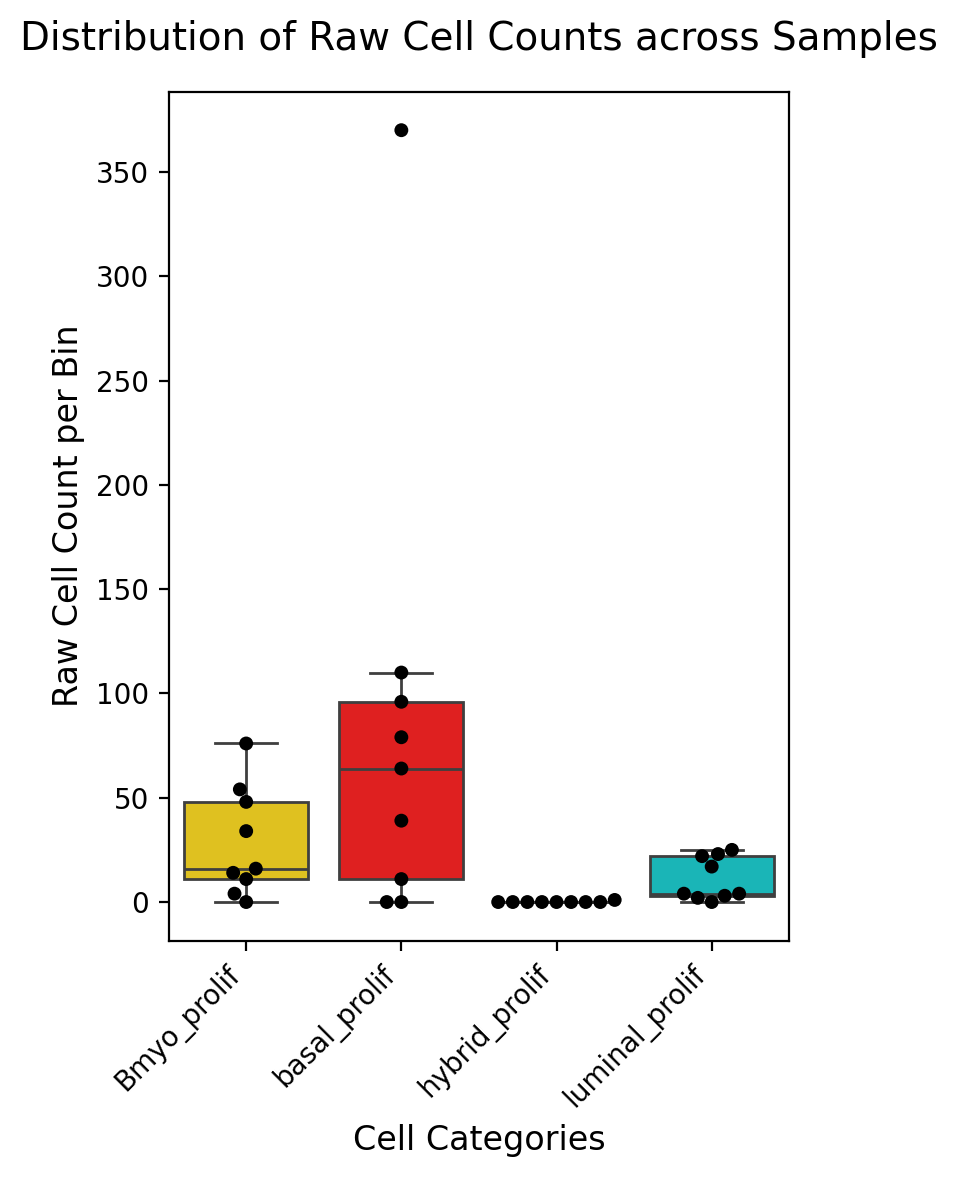

In [298]:
subsub = sub[sub.obs['Cell.type.prolif'].isin(['Bmyo_prolif','basal_prolif','hybrid_prolif','luminal_prolif'])]
df_meta = subsub.obs[['hyper_roi_3', 'Cell.type.prolif']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['hyper_roi_3', 'Cell.type.prolif'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo_prolif': 'gold',     # Nice slate blue
    'basal_prolif': 'red',     # Orange
    'hybrid_prolif': 'lightgray', # Green
    'luminal_prolif': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell.type.prolif',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('MUT_hyperplasia_ROI_proliferation_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

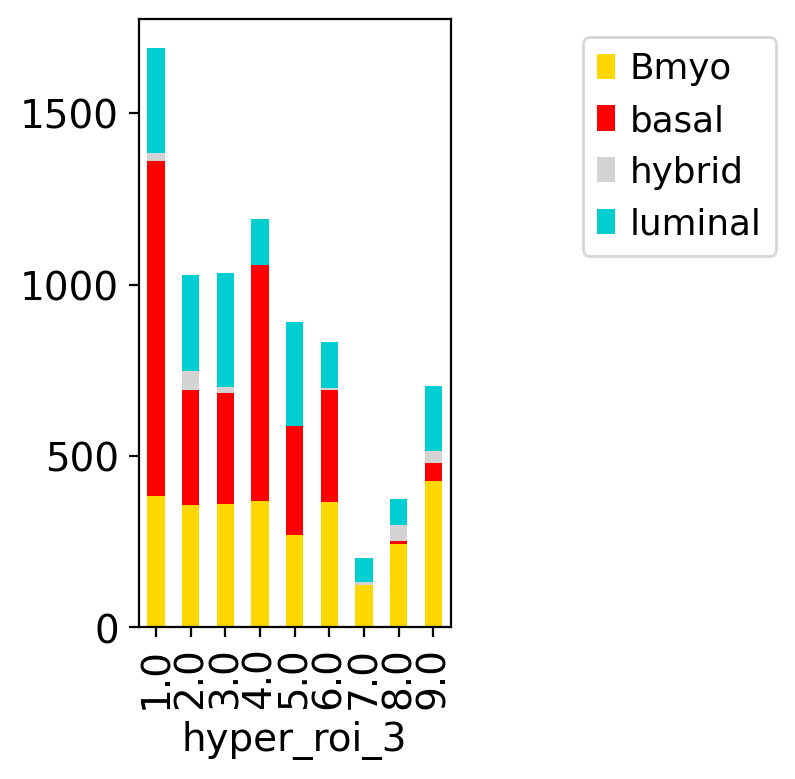

In [124]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['hyper_roi_3']).T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_stackedbar_plot.pdf', bbox_inches='tight')

/tmp/ipykernel_81008/1999517890.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['hyper_roi_3', 'Cell_type_basal_hybrid'])
/tmp/ipykernel_81008/1999517890.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/1999517890.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts,


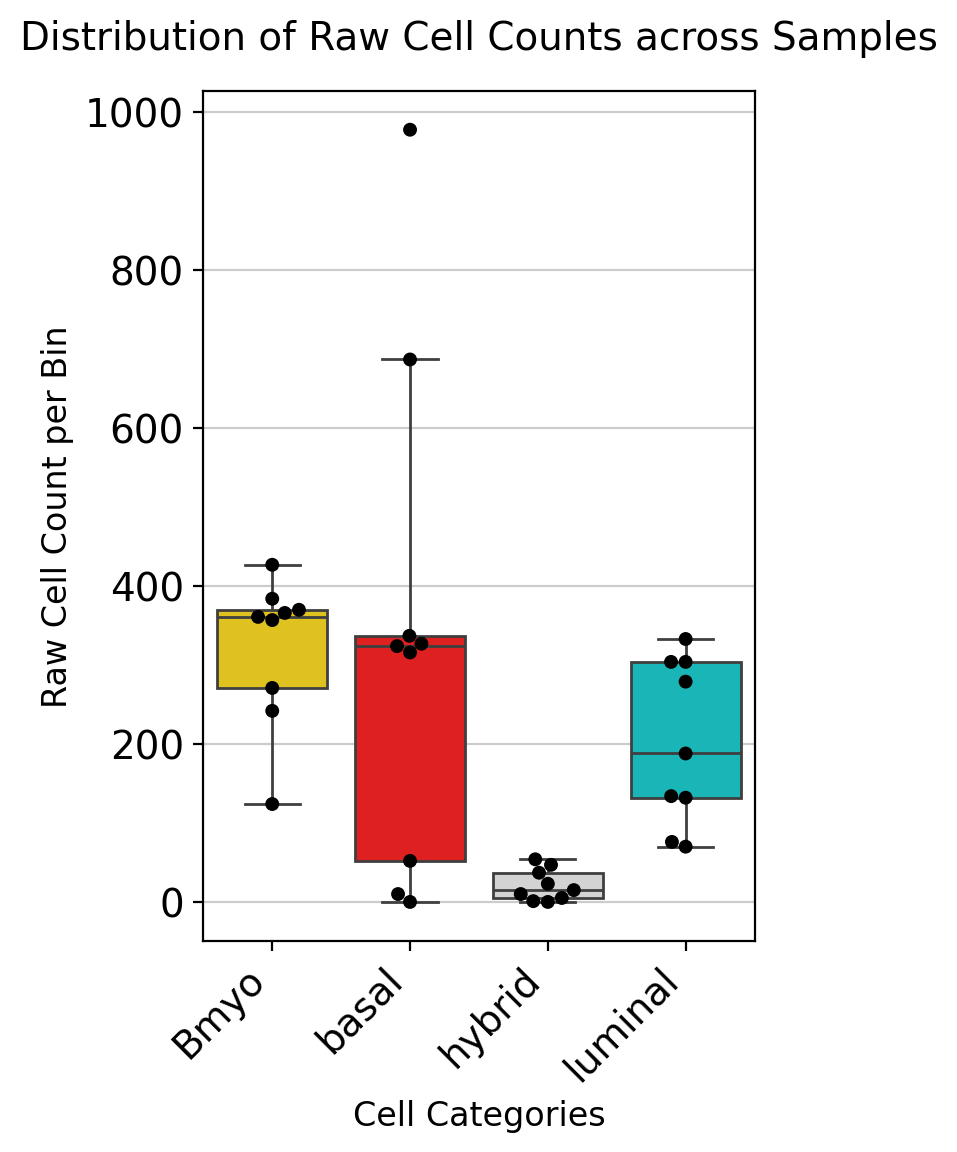

In [125]:
df_meta = sub.obs[['hyper_roi_3', 'Cell_type_basal_hybrid']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['hyper_roi_3', 'Cell_type_basal_hybrid'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo': 'gold',     # Nice slate blue
    'basal': 'red',     # Orange
    'hybrid': 'lightgray', # Green
    'luminal': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell_type_basal_hybrid',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('MUT_hyper_ROI_cell_counts_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

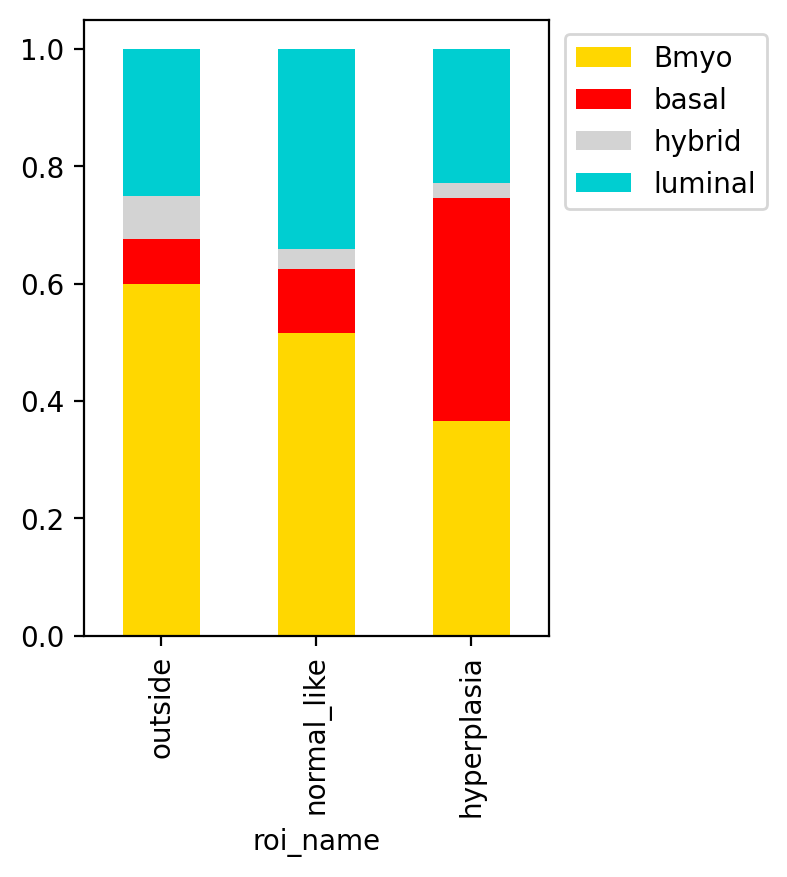

In [118]:
pl.rcParams["figure.figsize"] = (3,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name'], 
                  normalize='columns').reindex()[['outside',
                                                  'normal_like',
                                                 'hyperplasia']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_MUT_stackedbar_plot.pdf', bbox_inches='tight')

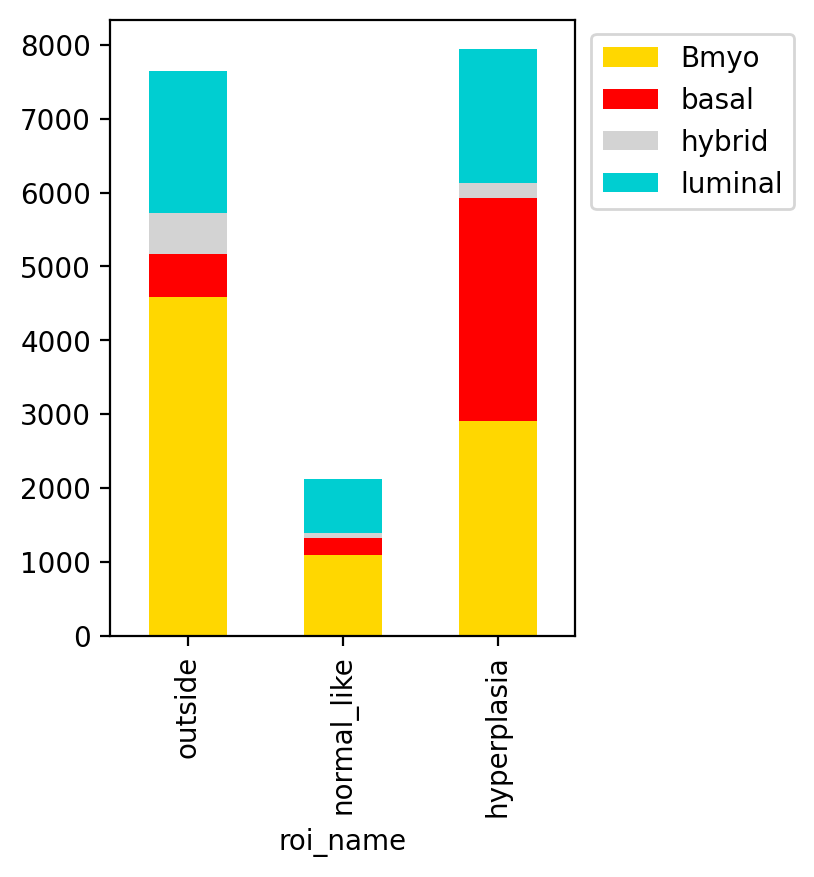

In [119]:
pl.rcParams["figure.figsize"] = (3,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name']).reindex()[['outside',
                                                  'normal_like',
                                                 'hyperplasia']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_MUT_raw_stackedbar_plot.pdf', bbox_inches='tight')

In [111]:
sub.obs['roi_name'] = sub.obs["roi_name"].astype("str")
sub.obs['Cell_type_basal_hybrid'] = sub.obs["Cell_type_basal_hybrid"].astype("str")
sub.obs['celltype_roi'] = sub.obs['Cell_type_basal_hybrid'] + ' ' + sub.obs['roi_name']

/tmp/ipykernel_27953/2816450357.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs['roi_name'] = sub.obs["roi_name"].astype("str")


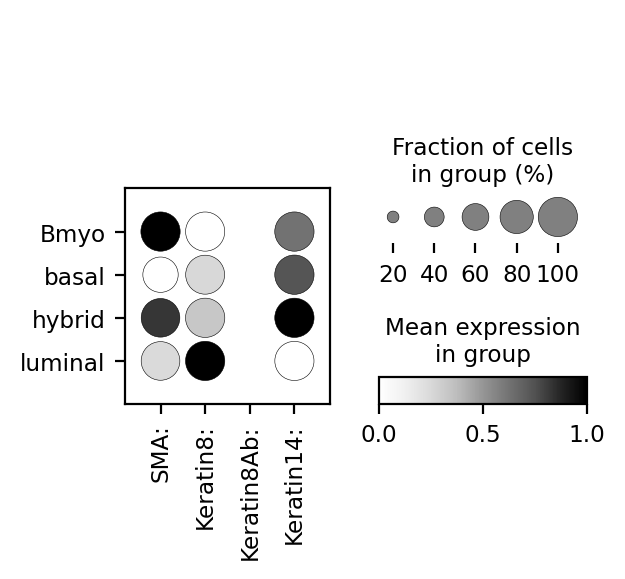

In [116]:
marker_genes = ["SMA:","Keratin8:","Keratin8Ab:","Keratin14:"]

plt.style.use('default')
sc.pl.dotplot(sub, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_mut_canonical.pdf'
             )

In [190]:
sub_norm=sub[sub.obs['roi_name'].isin(['normal_like'])]
sub_hyper=sub[sub.obs['roi_name'].isin(['hyperplasia'])]

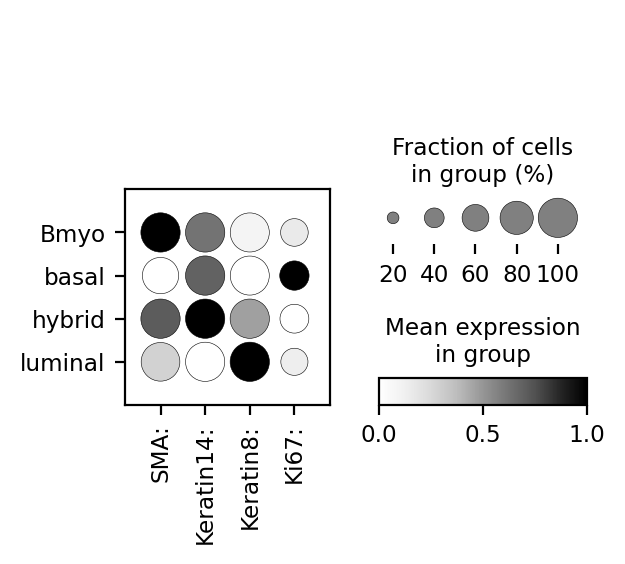

In [191]:
marker_genes = ["SMA:","Keratin14:","Keratin8:","Ki67:"]

plt.style.use('default')
sc.pl.dotplot(sub_norm, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_normal_like_mut_canonical.pdf'
             )

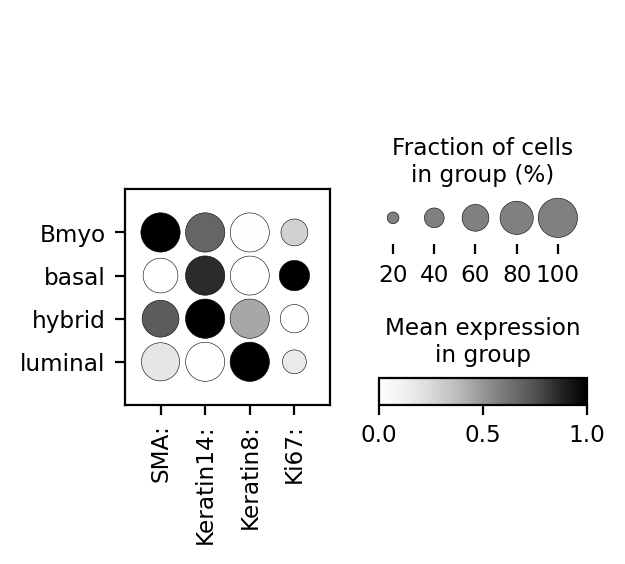

In [192]:
marker_genes = ["SMA:","Keratin14:","Keratin8:","Ki67:"]

plt.style.use('default')
sc.pl.dotplot(sub_hyper, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_hyperplasia_mut_canonical.pdf'
             )

In [299]:
#tum
sub = adata[adata.obs['sample'].isin(['tum_1','tum_2','tum_3'])]
sub.obs['sample'].value_counts()

sample
tum_2    54198
tum_1    38275
tum_3    23187
Name: count, dtype: int64

In [300]:
sub = sub[sub.obs['roi_name'].isin(['hyperplasia'])]
sub.obs['hyper_roi_3'].value_counts()

hyper_roi_3
1.0    8161
6.0    7799
5.0    6919
3.0    6605
2.0    6279
4.0    6058
8.0    4191
9.0    4180
7.0    3265
Name: count, dtype: int64

/tmp/ipykernel_81008/564676550.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['hyper_roi_3', 'Cell.type.prolif'])
/tmp/ipykernel_81008/564676550.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/564676550.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts,


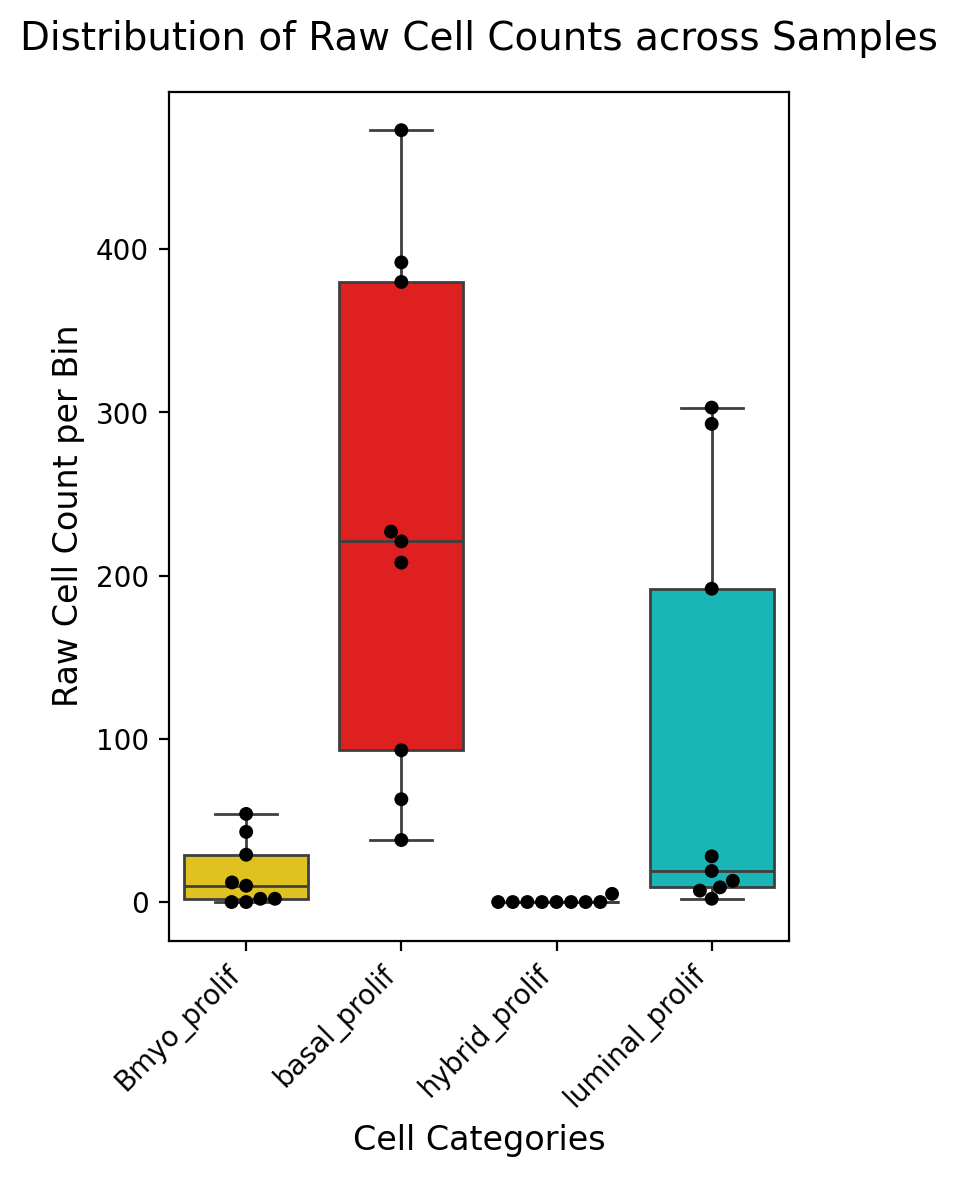

In [301]:
subsub = sub[sub.obs['Cell.type.prolif'].isin(['Bmyo_prolif','basal_prolif','hybrid_prolif','luminal_prolif'])]
df_meta = subsub.obs[['hyper_roi_3', 'Cell.type.prolif']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['hyper_roi_3', 'Cell.type.prolif'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo_prolif': 'gold',     # Nice slate blue
    'basal_prolif': 'red',     # Orange
    'hybrid_prolif': 'lightgray', # Green
    'luminal_prolif': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell.type.prolif',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell.type.prolif', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('TUMhyperplasia_ROI_proliferation_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

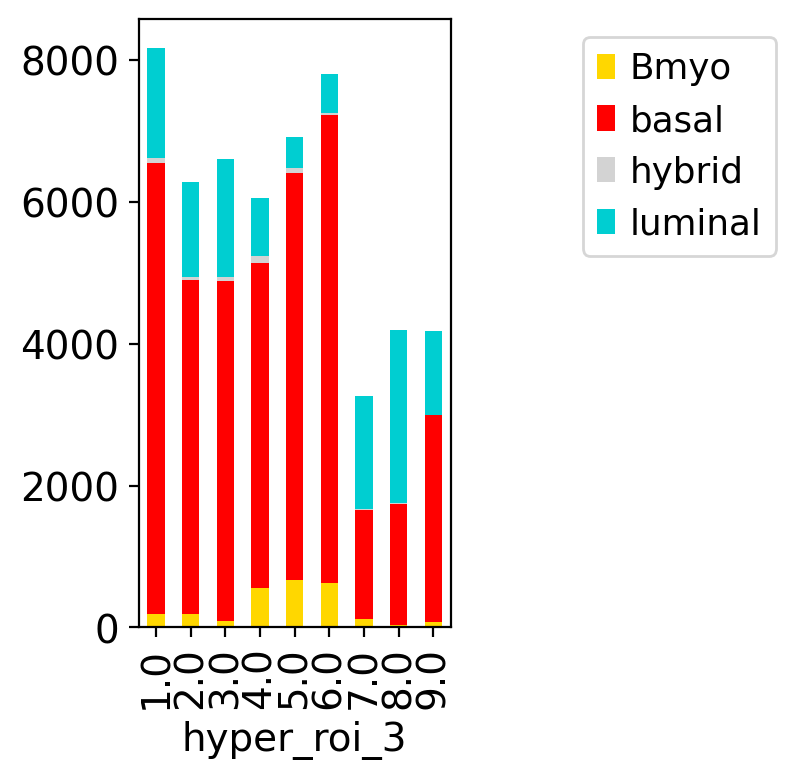

In [128]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['hyper_roi_3']).T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

#pl.savefig('Fig_6_WT_stackedbar_plot.pdf', bbox_inches='tight')

/tmp/ipykernel_81008/2581850820.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_meta.groupby(['hyper_roi_3', 'Cell_type_basal_hybrid'])
/tmp/ipykernel_81008/2581850820.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_81008/2581850820.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts,
/opt/apps/python/3.10.2/lib/python3.10/site-packages/seaborn/categorical.py:3399: UserWarning: 22.2% of the points cannot 

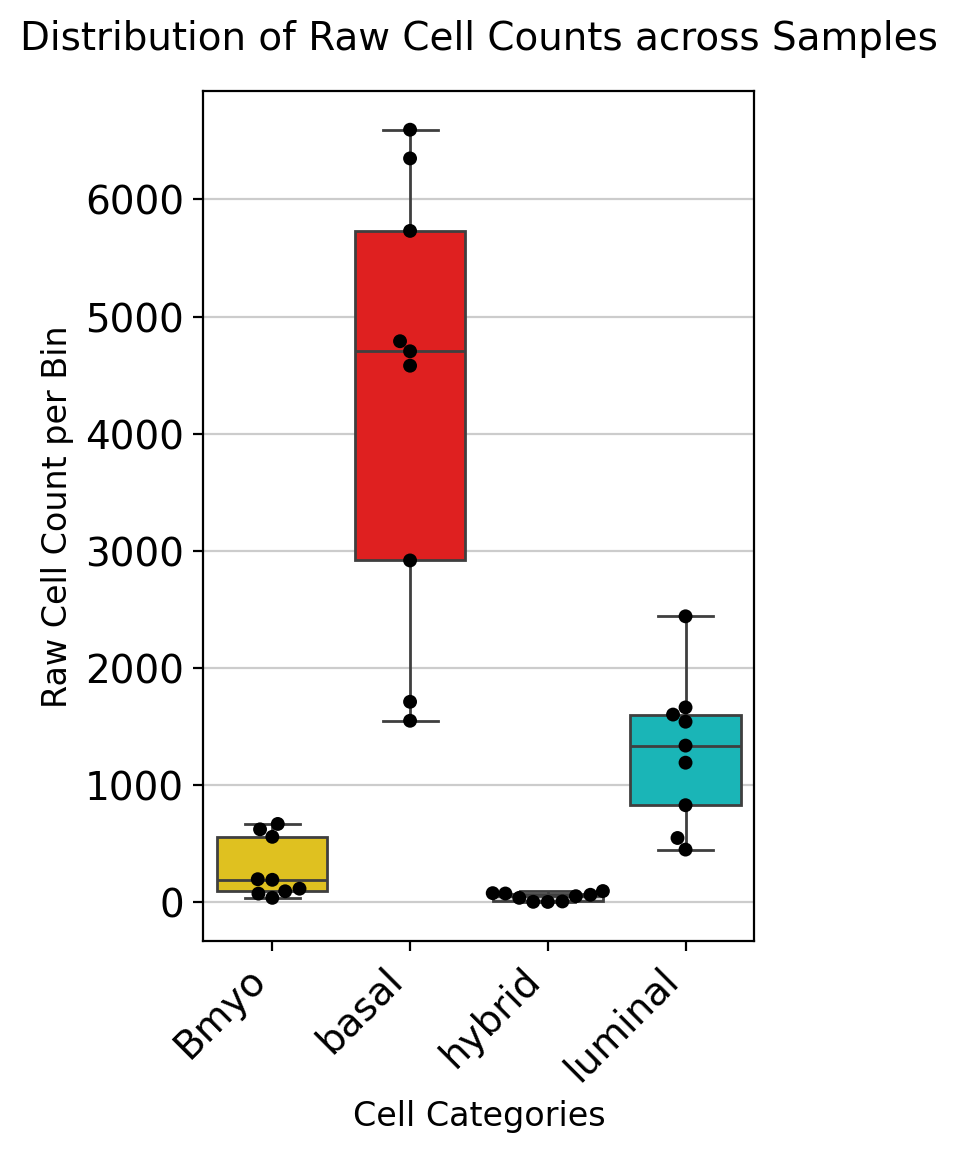

In [129]:
df_meta = sub.obs[['hyper_roi_3', 'Cell_type_basal_hybrid']].copy()

# 2. Compute the RAW cell counts per sample for each category
df_raw_counts = (
    df_meta.groupby(['hyper_roi_3', 'Cell_type_basal_hybrid'])
    .size()
    .reset_index(name='raw_cell_count')
)



custom_colors = {
    'Bmyo': 'gold',     # Nice slate blue
    'basal': 'red',     # Orange
    'hybrid': 'lightgray', # Green
    'luminal': 'darkturquoise'     # Red
}


# 3. Plot the distribution of raw values
plt.figure(figsize=(4, 6))
sns.boxplot(
    data=df_raw_counts, 
    x='Cell_type_basal_hybrid',        # Each category gets its own box
    y='raw_cell_count',   # The raw count values on the y-axis
    palette=custom_colors,     # Colors the boxplots
    showfliers=False
)

sns.swarmplot(x='Cell_type_basal_hybrid', y='raw_cell_count', data=df_raw_counts, 
              palette=['black','black','black','black'], marker='o', s=5)

# 5. Customize text and labels
plt.title('Distribution of Raw Cell Counts across Samples', fontsize=14, pad=15)
plt.xlabel('Cell Categories', fontsize=12)
plt.ylabel('Raw Cell Count per Bin', fontsize=12)
plt.xticks(rotation=45, ha='right') # 'ha' aligns text nicely when rotated
plt.tight_layout()

# 6. SAVE AS PDF (Change 'cell_counts_boxplot.pdf' to your preferred filename)
plt.savefig('TUM_hyper_ROI_cell_counts_boxplot.pdf', format='pdf', bbox_inches='tight', dpi=300)

# 7. Render on screen
plt.show()

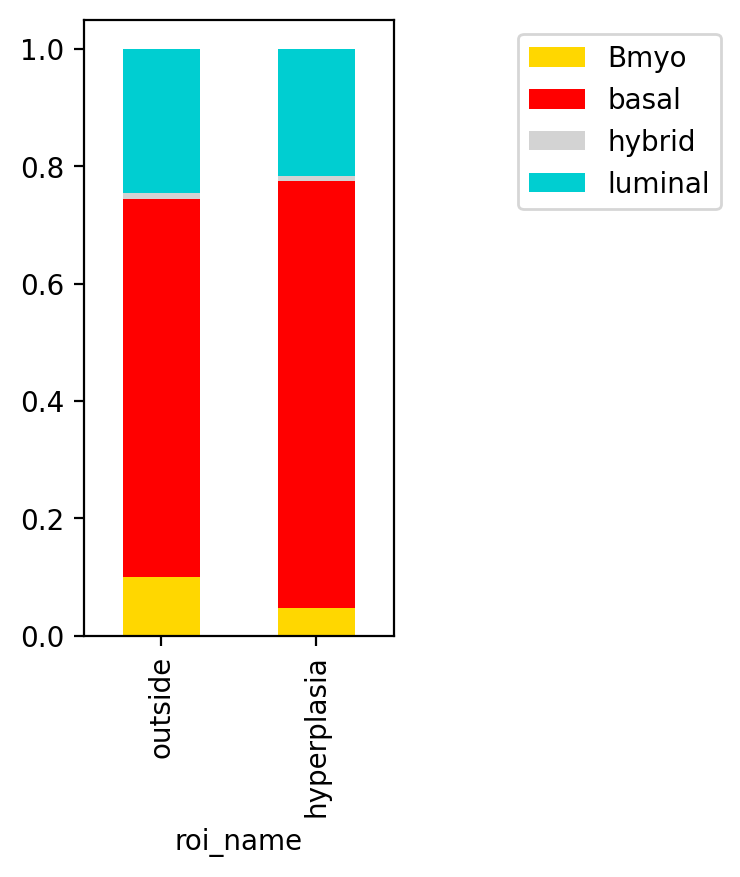

In [105]:
pl.rcParams["figure.figsize"] = (2,4)

tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name'], 
                  normalize='columns').reindex()[['outside',
                                                 'hyperplasia']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_TUM_stackedbar_plot.pdf', bbox_inches='tight')

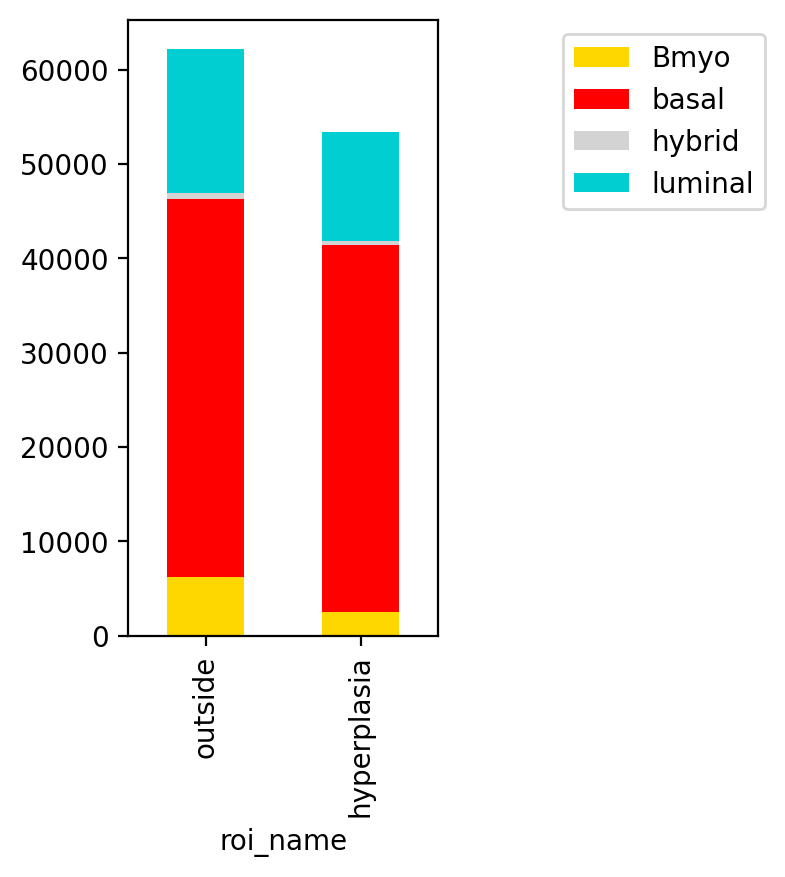

In [102]:
pl.rcParams["figure.figsize"] = (2,4)


tmp = pd.crosstab(sub.obs['Cell_type_basal_hybrid'],sub.obs['roi_name']).reindex()[['outside',
                                                 'hyperplasia']].T.plot(kind='bar', stacked=True, color=['gold',
                                                                              'red',
                                                                              'lightgray',
                                                                              'darkturquoise'])
tmp.legend(title='', bbox_to_anchor=(2.1, 1.0),loc='upper right')
plt.grid(False)

pl.savefig('Fig_6_TUM_raw_stackedbar_plot.pdf', bbox_inches='tight')

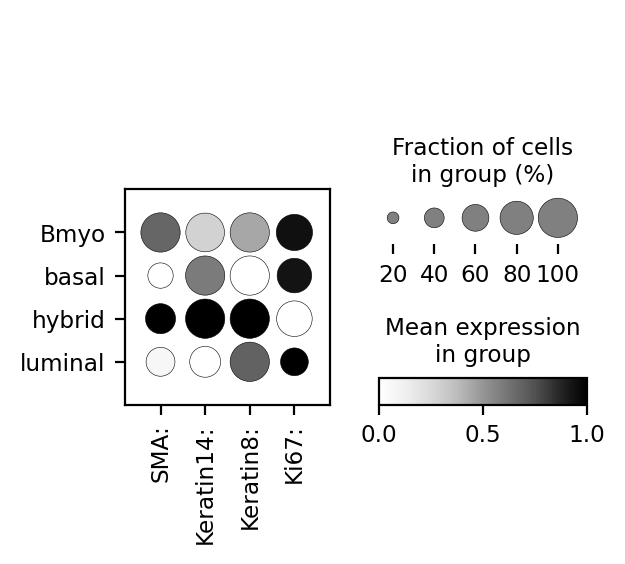

In [194]:
marker_genes = ["SMA:","Keratin14:","Keratin8:","Ki67:"]

plt.style.use('default')
sc.pl.dotplot(sub, marker_genes, groupby="Cell_type_basal_hybrid",
              standard_scale="var",swap_axes=False,cmap='Greys',
              save='_tum_canonical.pdf'
             )